In [5]:
# Import all the libraries I need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Import functions from sklearn for building the model, training-testing split, visualising the model and metrics 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [6]:
# importing the dataset
df = pd.read_csv('data/Churn_Modelling.csv')

In [7]:
df.head()   

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
# RowNumber --> This is just an index and does not provide any useful information for the model, so we can drop it.
# CustomerId --> This is a unique identifier for each customer and does not provide any useful information for the model, so we can drop it.
# Surname --> This is a unique identifier for each customer and does not provide any useful information for the model, so we can drop it.
# Geography --> This is a categorical variable that indicates the country of residence of the customer. We can convert this variable into dummy variables (one-hot encoding) to use it in our model.
# Gender --> This is a categorical variable that indicates the gender of the customer. We can convert this variable into dummy variables (one-hot encoding) to use it in our model.
# CreditScore --> This is a numerical variable that indicates the credit score of the customer. We can use this variable as it is in our model.
# Age --> This is a numerical variable that indicates the age of the customer. We can use this variable as it is in our model.
# Tenure --> This is a numerical variable that indicates the number of years the customer has been with the bank. We can use this variable as it is in our model.
# Balance --> This is a numerical variable that indicates the balance of the customer's account. We can use this variable as it is in our model.
# NumOfProducts --> This is a numerical variable that indicates the number of products the customer has with the bank. We can use this variable as it is in our model.
# HasCrCard --> This is a binary variable that indicates whether the customer has a credit card or not. We can use this variable as it is in our model.
# IsActiveMember --> This is a binary variable that indicates whether the customer is an active member or not. We can use this variable as it is in our model.
# EstimatedSalary --> This is a numerical variable that indicates the estimated salary of the customer. We can use this variable as it is in our model.
# Exited --> This is the target variable that indicates whether the customer has churned or not. We can use this variable as it is in our model. 
# Depentent Variable/ Target Variable(Exited): 1 indicates that the customer has churned, while 0 indicates that the customer has not churned.


In [9]:
df.shape # (10000, 14)

(10000, 14)

In [10]:
# The dataset has 10,000 rows and 14 columns.
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [11]:
df.isnull().sum() # There are no missing values in the dataset.

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
df.describe() # The dataset has a wide range of values for the numerical variables, which may require scaling before training the model.

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [13]:
df["Exited"].value_counts() # The target variable is imbalanced, with more customers who have not churned than those who have churned. This may require techniques such as oversampling or undersampling to balance the classes before training the model.

Exited
0    7963
1    2037
Name: count, dtype: int64

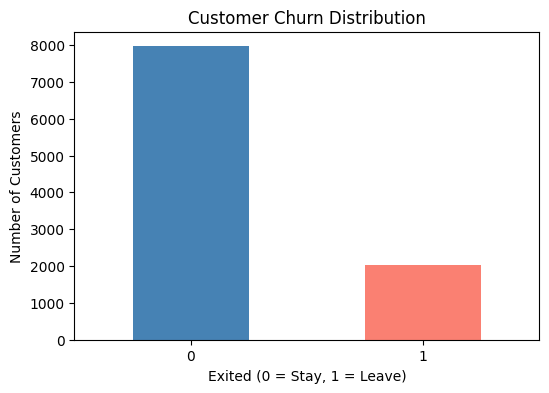

In [14]:
# Exploratory Data Analysis (EDA)

plt.figure(figsize=(6,4))

df["Exited"].value_counts().plot(
    kind='bar',
    color=['steelblue','salmon']
)

plt.title('Customer Churn Distribution')
plt.xlabel('Exited (0 = Stay, 1 = Leave)')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

In [15]:
df.groupby('Exited')['Age'].mean() # The average age of customers who have churned is higher than that of customers who have not churned, suggesting that older customers may be more likely to churn.

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

In [16]:
df.groupby('Exited')['Tenure'].mean() # The average tenure of customers who have churned is lower than that of customers who have not churned, suggesting that customers who have been with the bank for a shorter period of time may be more likely to churn.

Exited
0    5.033279
1    4.932744
Name: Tenure, dtype: float64

In [17]:
df.groupby(['Exited', 'Gender'])['Balance'].mean() # The average balance of customers who have churned is higher than that of customers who have not churned, suggesting that customers with higher balances may be more likely to churn. 
                                                   # Additionally, the average balance for male customers who have churned is higher than that for female customers who have churned.

Exited  Gender
0       Female    71183.249639
        Male      73911.607037
1       Female    89036.639359
        Male      93736.483742
Name: Balance, dtype: float64

In [18]:
df.groupby('Exited')['Balance'].mean() # The average balance of customers who have churned is higher than that of customers who have not churned, suggesting that customers with higher balances may be more likely to churn.
# This was also observed in the previous analysis where we grouped by both 'Exited' and 'Gender'.

Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64

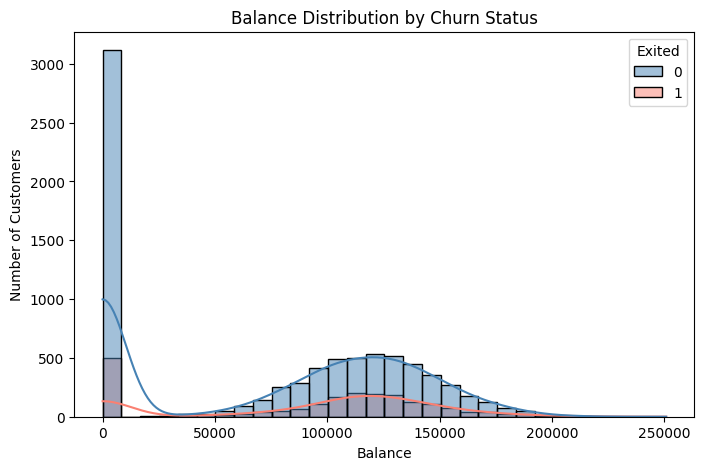

In [19]:
# The histogram shows that the distribution of balances for customers who have churned is skewed towards higher balances, while the distribution for customers who have not churned is more evenly distributed across different balance ranges. 
# This further supports the observation that customers with higher balances may be more likely to churn.
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Balance',
    hue='Exited',
    bins=30,
    kde=True,
    palette=['steelblue','salmon']
)

plt.title('Balance Distribution by Churn Status')
plt.xlabel('Balance')
plt.ylabel('Number of Customers')
plt.show()

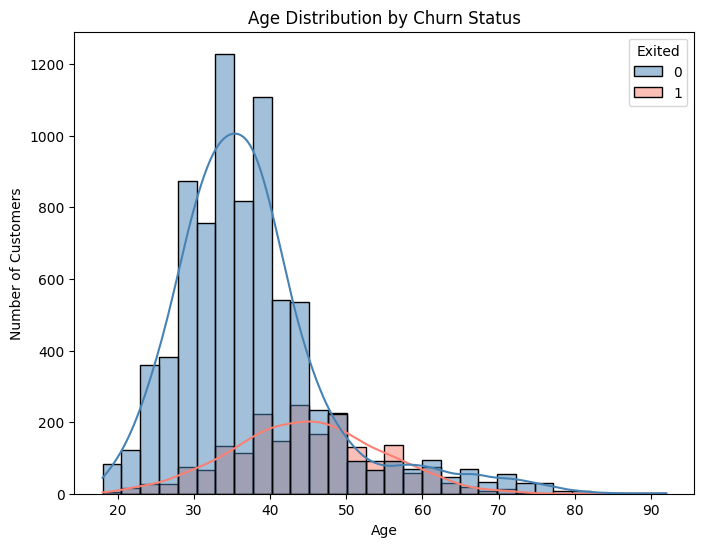

In [20]:
# The histogram shows that the distribution of ages for customers who have churned is skewed towards older ages, while the distribution for customers who have not churned is more evenly distributed across different age ranges.
# This supports the observation that older customers may be more likely to churn.

plt.figure(figsize=(8,6))
sns.histplot(
    data=df,
    x='Age',
    hue='Exited',
    bins=30,
    kde=True,
    palette=['steelblue','salmon']
)   
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()



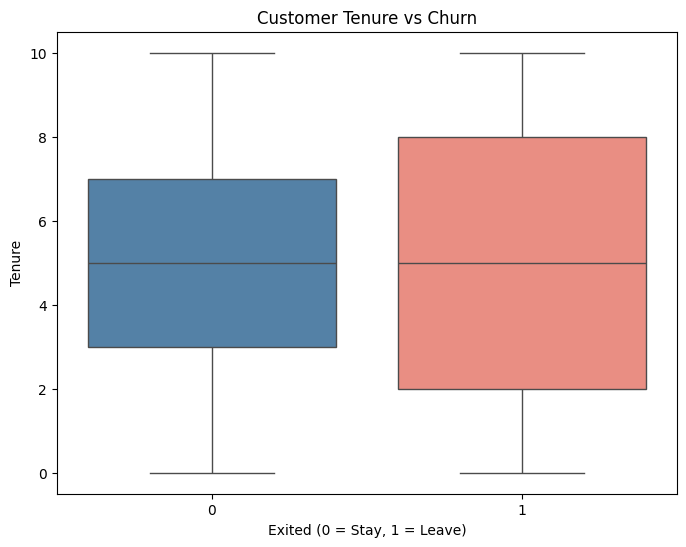

In [21]:
# Plot of Tenure

plt.figure(figsize=(8,6))

sns.boxplot(x='Exited', y='Tenure', data=df, palette=['steelblue','salmon'])

plt.title('Customer Tenure vs Churn')
plt.xlabel('Exited (0 = Stay, 1 = Leave)')
plt.ylabel('Tenure')

plt.show()

In [22]:
# fe